In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'normal',
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 12,
})

BLUE   = '#2a78d6'
GREEN  = '#1baf7a'
PURPLE = '#4a3aa7'
RED    = '#e34948'
AMBER  = '#eda100'
GREY   = '#73726c'
LGREY  = '#f2f4f8'

FIG_PATH = r'C:\Users\namra\gluten-free-spatial-inequality\outputs\figures'
TAB_PATH = r'C:\Users\namra\gluten-free-spatial-inequality\outputs\tables'

# ── data ───────────────────────────────────────────────────────────────────
df = pd.read_csv(r'C:\Users\namra\gluten-free-spatial-inequality\data\processed\analytical_dataset_final.csv')
df_presc = pd.read_csv(r'C:\Users\namra\gluten-free-spatial-inequality\data\raw\gf_prescribing_subicb.csv')
df_presc['date'] = pd.to_datetime(df_presc['date'])

print(f"Analytical dataset: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Analytical dataset: (106, 23)
Columns: ['org_id', 'org_name', 'prescribing_rate_mean', 'prescribing_rate_median', 'prescribing_rate_max', 'months_zero', 'imd_score_mean', 'income_score_mean', 'health_score_mean', 'education_score_mean', 'retail_accessibility_score', 'total_stores', 'quality_stores', 'regular_stores', 'budget_stores', 'n_lsoas', 'quadrant', 'imd_quintile', 'prescribing_rate_recent', 'imd_score_weighted', 'trend_slope', 'trend_pvalue', 'trend_r2']


In [3]:
# ── SECTION 1: AXIS 1 — NHS GF PRESCRIBING PROVISION ──────────────────────

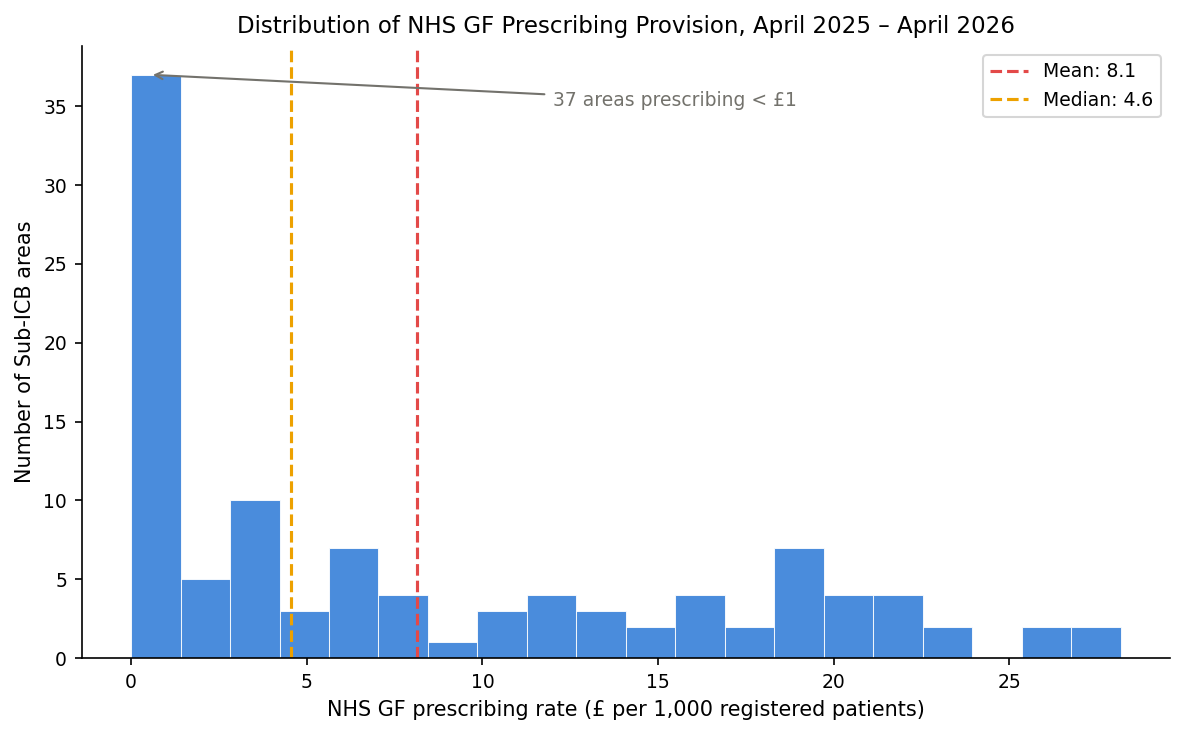

Saved 1a.


In [4]:
# Plot 1a — Distribution
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df['prescribing_rate_recent'], bins=20, color=BLUE,
        alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axvline(df['prescribing_rate_recent'].mean(), color=RED,
           linewidth=1.5, linestyle='--',
           label=f"Mean: {df['prescribing_rate_recent'].mean():.1f}")
ax.axvline(df['prescribing_rate_recent'].median(), color=AMBER,
           linewidth=1.5, linestyle='--',
           label=f"Median: {df['prescribing_rate_recent'].median():.1f}")
ax.set_xlabel('NHS GF prescribing rate (£ per 1,000 registered patients)')
ax.set_ylabel('Number of Sub-ICB areas')
ax.set_title('Distribution of NHS GF Prescribing Provision, April 2025 – April 2026')
ax.legend()
ax.annotate(f'37 areas prescribing < £1',
            xy=(0.5, 37), xytext=(12, 35),
            arrowprops=dict(arrowstyle='->', color=GREY, lw=1),
            fontsize=9, color=GREY)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/EDA_01a_prescribing_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved 1a.")

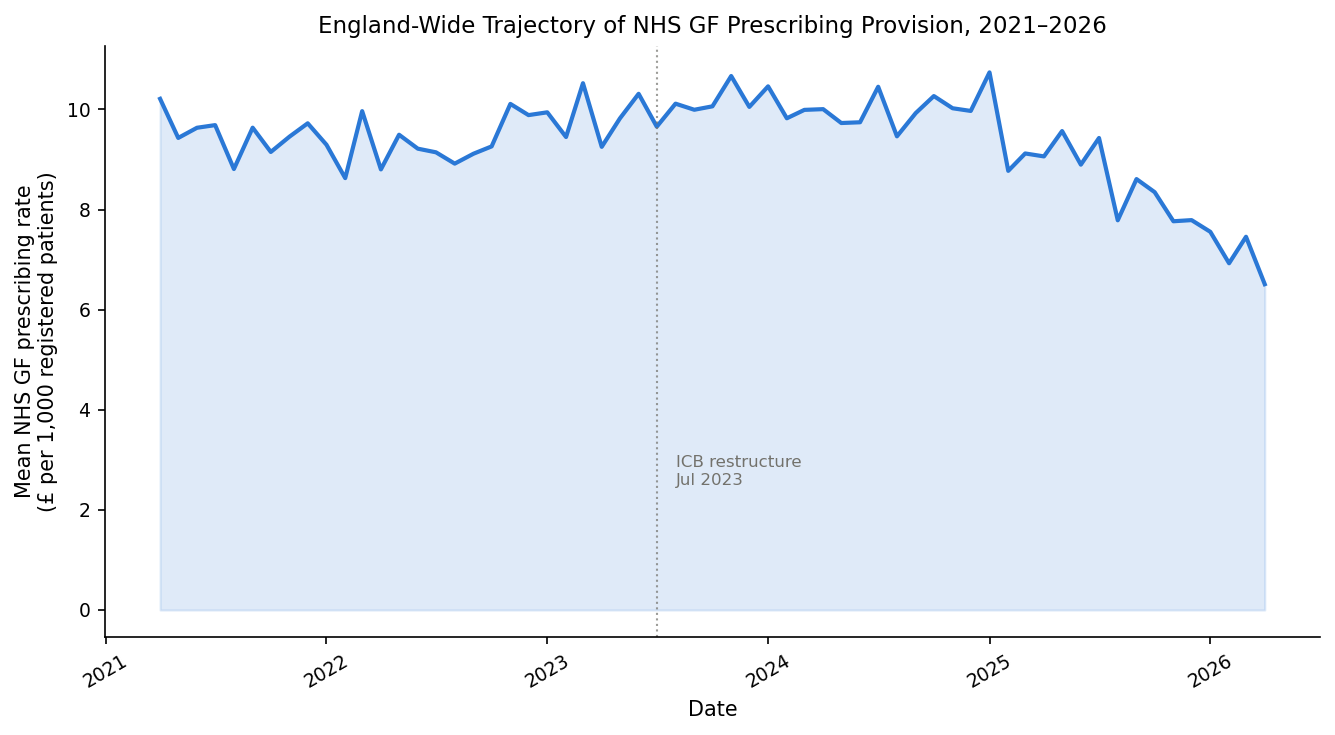

Saved 1b.


In [5]:
# Plot 1b — Temporal trajectory
fig, ax = plt.subplots(figsize=(9, 5))

eng_trend = df_presc.groupby('date')['calc_value'].mean().reset_index()
ax.plot(eng_trend['date'], eng_trend['calc_value'], color=BLUE, linewidth=2)
ax.fill_between(eng_trend['date'], eng_trend['calc_value'], alpha=0.15, color=BLUE)
ax.axvline(pd.to_datetime('2023-07-01'), color=GREY,
           linewidth=1, linestyle=':', alpha=0.7)
ax.text(pd.to_datetime('2023-08-01'), 2.5, 'ICB restructure\nJul 2023',
        fontsize=8, color=GREY)
ax.set_xlabel('Date')
ax.set_ylabel('Mean NHS GF prescribing rate\n(£ per 1,000 registered patients)')
ax.set_title('England-Wide Trajectory of NHS GF Prescribing Provision, 2021–2026')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/EDA_01b_prescribing_trajectory.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved 1b.")

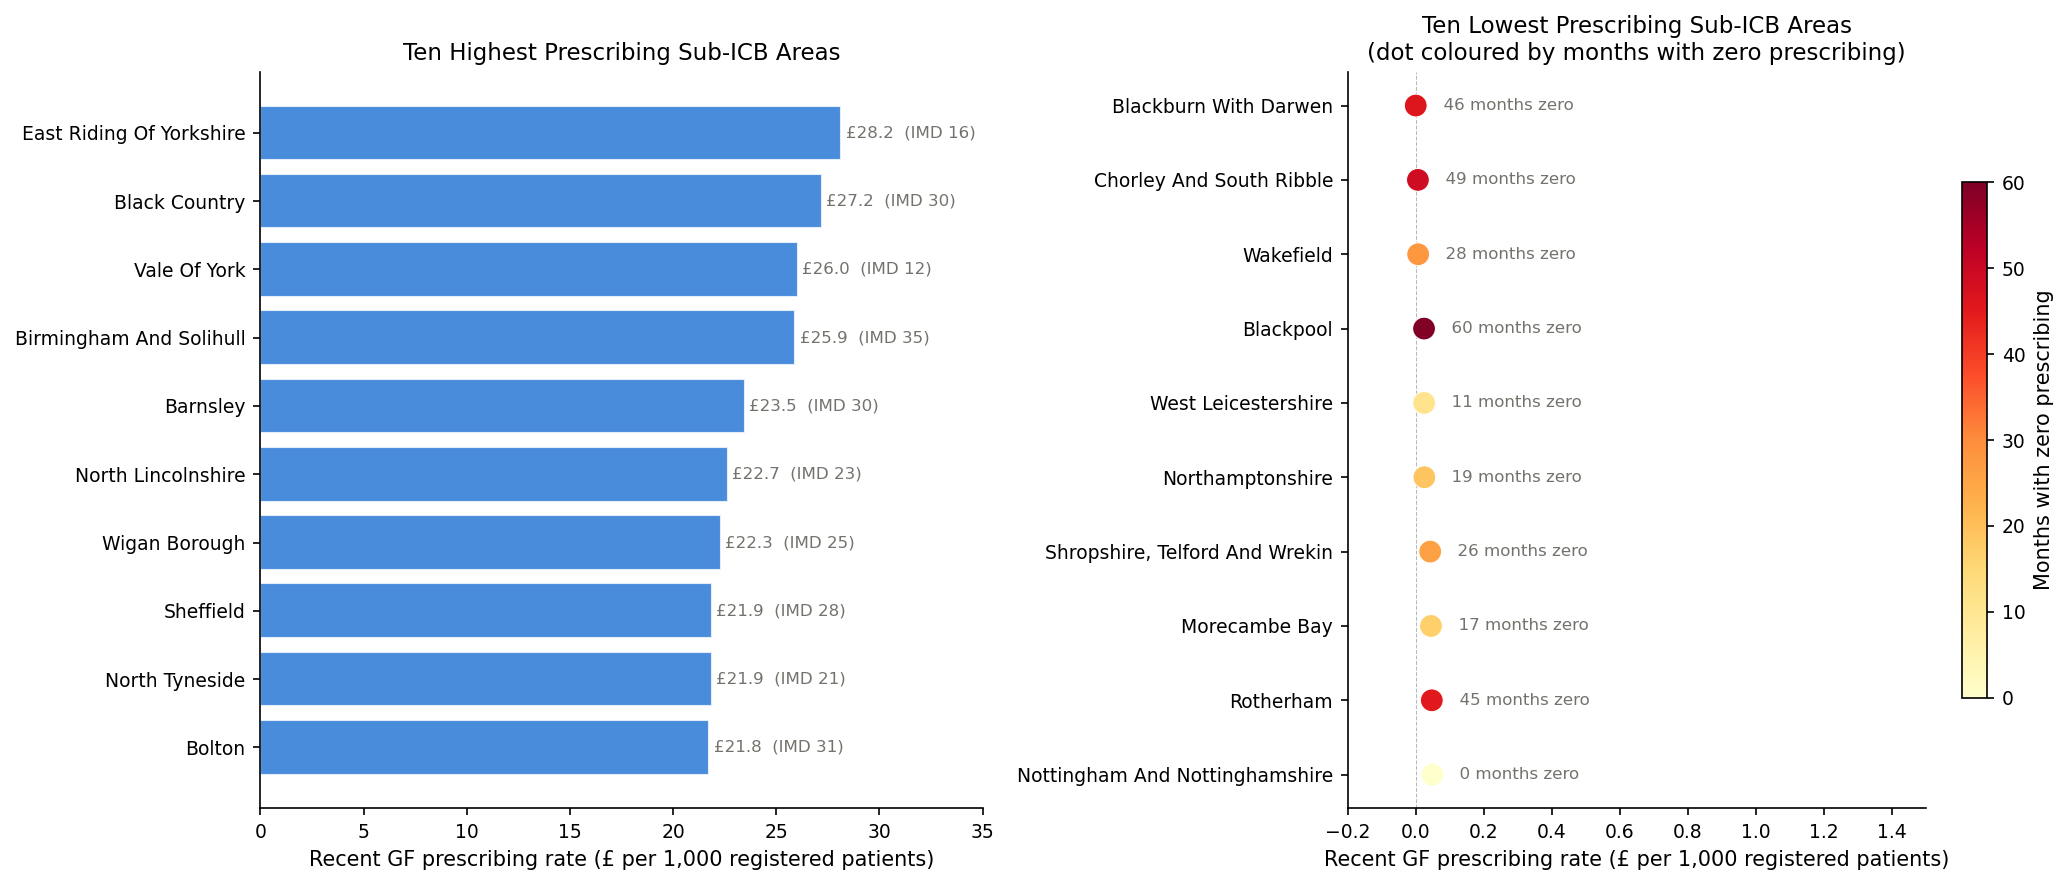

Saved 1c.


In [6]:
# Plot 1c — Top 10 highest prescribing only (bottom 10 are near-zero so shown in table)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: top 10
top10 = df.nlargest(10, 'prescribing_rate_recent')[
    ['org_name', 'prescribing_rate_recent', 'imd_score_weighted']
].sort_values('prescribing_rate_recent')
names_top = top10['org_name'].str.replace('NHS ', '').str.title()

axes[0].barh(range(10), top10['prescribing_rate_recent'],
             color=BLUE, alpha=0.85, edgecolor='white')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(names_top, fontsize=9)
axes[0].set_xlabel('Recent GF prescribing rate (£ per 1,000 registered patients)')
axes[0].set_title('Ten Highest Prescribing Sub-ICB Areas')
for i, (val, imd) in enumerate(zip(top10['prescribing_rate_recent'],
                                    top10['imd_score_weighted'])):
    axes[0].text(val + 0.2, i, f'£{val:.1f}  (IMD {imd:.0f})',
                 va='center', fontsize=8, color=GREY)
axes[0].set_xlim(0, 35)

# Right: bottom 10 as dot plot with months_zero
bot10 = df.nsmallest(10, 'prescribing_rate_recent')[
    ['org_name', 'prescribing_rate_recent', 'months_zero', 'imd_score_weighted']
].sort_values('prescribing_rate_recent', ascending=False)
names_bot = bot10['org_name'].str.replace('NHS ', '').str.title()

scatter = axes[1].scatter(bot10['prescribing_rate_recent'], range(10),
                          c=bot10['months_zero'], cmap='YlOrRd',
                          s=120, zorder=3, edgecolors='white', linewidth=0.5)
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(names_bot, fontsize=9)
axes[1].set_xlabel('Recent GF prescribing rate (£ per 1,000 registered patients)')
axes[1].set_title('Ten Lowest Prescribing Sub-ICB Areas\n(dot coloured by months with zero prescribing)')
axes[1].axvline(0, color=GREY, linewidth=0.5, linestyle='--', alpha=0.5)
for i, (val, mz) in enumerate(zip(bot10['prescribing_rate_recent'],
                                   bot10['months_zero'])):
    axes[1].text(val + 0.05, i, f'  {mz} months zero',
                 va='center', fontsize=8, color=GREY)
axes[1].set_xlim(-0.2, 1.5)
plt.colorbar(scatter, ax=axes[1], label='Months with zero prescribing', shrink=0.7)

plt.tight_layout()
plt.savefig(f'{FIG_PATH}/EDA_01c_top_bottom_areas.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved 1c.")

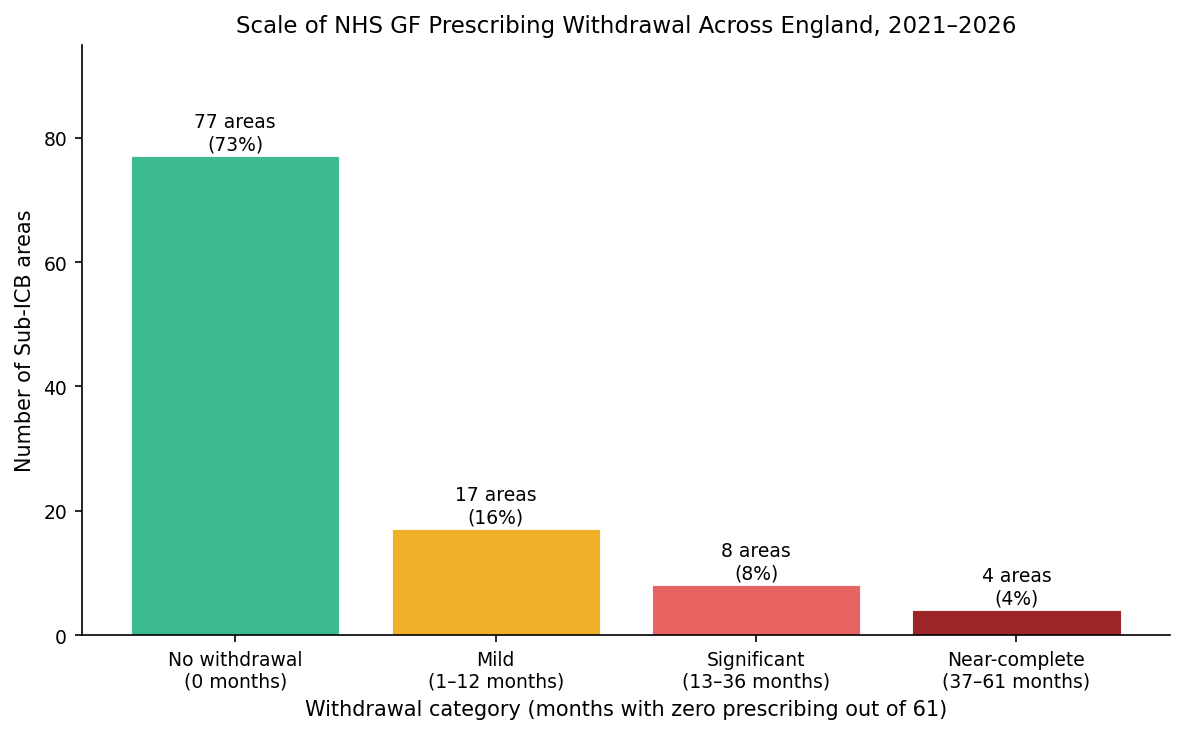

Saved 1d.


In [7]:
# Plot 1d — Withdrawal categories
fig, ax = plt.subplots(figsize=(8, 5))

withdrawal_cats = pd.cut(df['months_zero'],
    bins=[-1, 0, 12, 36, 61],
    labels=['No withdrawal\n(0 months)', 'Mild\n(1–12 months)',
            'Significant\n(13–36 months)', 'Near-complete\n(37–61 months)'])
counts = withdrawal_cats.value_counts().sort_index()
colors_w = [GREEN, AMBER, RED, '#8b0000']

bars = ax.bar(counts.index, counts.values, color=colors_w,
              alpha=0.85, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val} areas\n({val/106*100:.0f}%)',
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Number of Sub-ICB areas')
ax.set_xlabel('Withdrawal category (months with zero prescribing out of 61)')
ax.set_title('Scale of NHS GF Prescribing Withdrawal Across England, 2021–2026')
ax.set_ylim(0, 95)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/EDA_01d_withdrawal.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved 1d.")

In [8]:
# ── SECTION 2: AXIS 2 — GF RETAIL ACCESSIBILITY ───────────────────────────

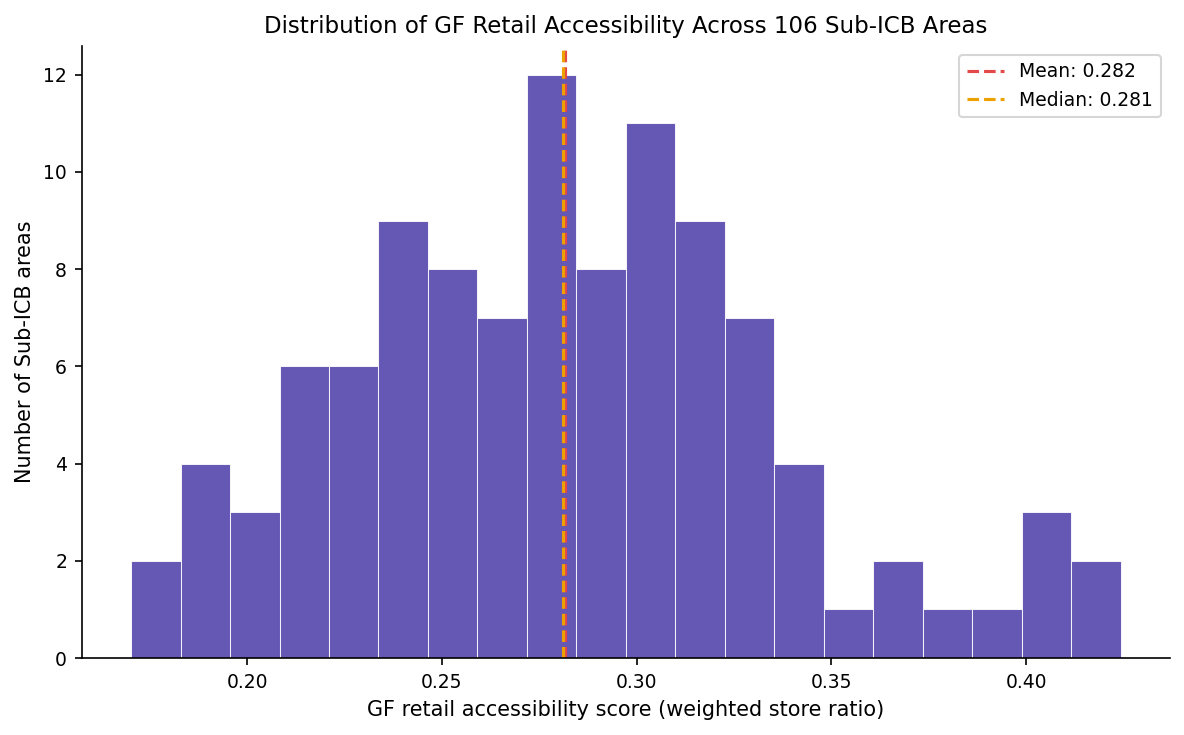

Saved 2a.


In [9]:
# Plot 2a — Distribution of retail accessibility score
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df['retail_accessibility_score'], bins=20, color=PURPLE,
        alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axvline(df['retail_accessibility_score'].mean(), color=RED,
           linewidth=1.5, linestyle='--',
           label=f"Mean: {df['retail_accessibility_score'].mean():.3f}")
ax.axvline(df['retail_accessibility_score'].median(), color=AMBER,
           linewidth=1.5, linestyle='--',
           label=f"Median: {df['retail_accessibility_score'].median():.3f}")
ax.set_xlabel('GF retail accessibility score (weighted store ratio)')
ax.set_ylabel('Number of Sub-ICB areas')
ax.set_title('Distribution of GF Retail Accessibility Across 106 Sub-ICB Areas')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/EDA_02a_retail_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved 2a.")

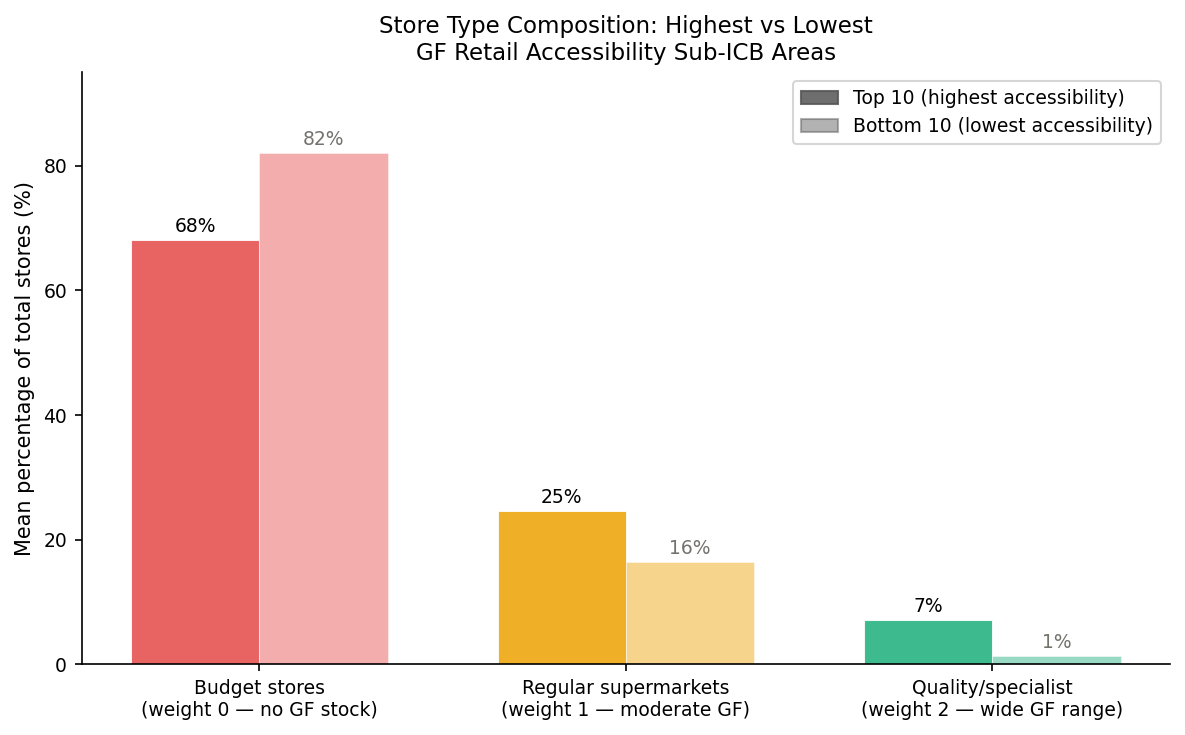

Saved 2b revised.


In [12]:
# Plot 2b: mean store composition top vs bottom 10
fig, ax = plt.subplots(figsize=(8, 5))

top10_r = df.nlargest(10, 'retail_accessibility_score')
bot10_r = df.nsmallest(10, 'retail_accessibility_score')

groups = ['Top 10\n(highest accessibility)', 'Bottom 10\n(lowest accessibility)']

for group_df, label in [(top10_r, 'Top 10'), (bot10_r, 'Bottom 10')]:
    group_df = group_df.copy()
    group_df['budget_pct'] = group_df['budget_stores'] / group_df['total_stores'] * 100
    group_df['regular_pct'] = group_df['regular_stores'] / group_df['total_stores'] * 100
    group_df['quality_pct'] = group_df['quality_stores'] / group_df['total_stores'] * 100
    if label == 'Top 10':
        top_means = [group_df['budget_pct'].mean(),
                     group_df['regular_pct'].mean(),
                     group_df['quality_pct'].mean()]
    else:
        bot_means = [group_df['budget_pct'].mean(),
                     group_df['regular_pct'].mean(),
                     group_df['quality_pct'].mean()]

x = np.arange(3)
width = 0.35
store_labels = ['Budget stores\n(weight 0 — no GF stock)',
                'Regular supermarkets\n(weight 1 — moderate GF)',
                'Quality/specialist\n(weight 2 — wide GF range)']
colors_s = [RED, AMBER, GREEN]

bars1 = ax.bar(x - width/2, top_means, width, color=colors_s,
               alpha=0.85, edgecolor='white', linewidth=0.5, label='_nolegend_')
bars2 = ax.bar(x + width/2, bot_means, width, color=colors_s,
               alpha=0.45, edgecolor='white', linewidth=0.5, label='_nolegend_')

for bar, val in zip(bars1, top_means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='500')
for bar, val in zip(bars2, bot_means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=9, color=GREY)

ax.set_xticks(x)
ax.set_xticklabels(store_labels, fontsize=9)
ax.set_ylabel('Mean percentage of total stores (%)')
ax.set_title('Store Type Composition: Highest vs Lowest\nGF Retail Accessibility Sub-ICB Areas')
ax.set_ylim(0, 95)

legend_handles = [
    mpatches.Patch(color='#555', alpha=0.85, label='Top 10 (highest accessibility)'),
    mpatches.Patch(color='#555', alpha=0.45, label='Bottom 10 (lowest accessibility)')
]
ax.legend(handles=legend_handles, fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/EDA_02b_store_composition.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved 2b revised.")

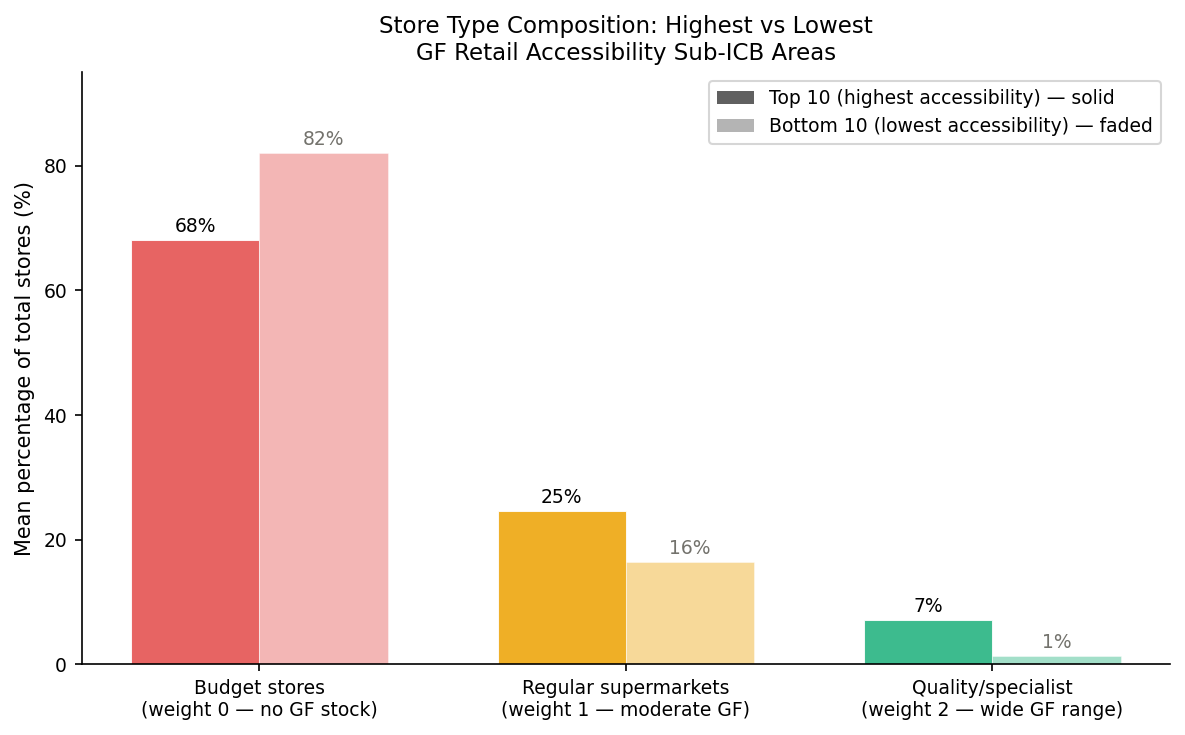

Saved 2b revised.


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

top10_r = df.nlargest(10, 'retail_accessibility_score').copy()
bot10_r = df.nsmallest(10, 'retail_accessibility_score').copy()

for group_df, label in [(top10_r, 'top'), (bot10_r, 'bot')]:
    group_df['budget_pct'] = group_df['budget_stores'] / group_df['total_stores'] * 100
    group_df['regular_pct'] = group_df['regular_stores'] / group_df['total_stores'] * 100
    group_df['quality_pct'] = group_df['quality_stores'] / group_df['total_stores'] * 100
    if label == 'top':
        top_means = [group_df['budget_pct'].mean(),
                     group_df['regular_pct'].mean(),
                     group_df['quality_pct'].mean()]
    else:
        bot_means = [group_df['budget_pct'].mean(),
                     group_df['regular_pct'].mean(),
                     group_df['quality_pct'].mean()]

x = np.arange(3)
width = 0.35
store_labels = ['Budget stores\n(weight 0 — no GF stock)',
                'Regular supermarkets\n(weight 1 — moderate GF)',
                'Quality/specialist\n(weight 2 — wide GF range)']
colors_s = [RED, AMBER, GREEN]

bars1 = ax.bar(x - width/2, top_means, width, color=colors_s,
               alpha=0.85, edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, bot_means, width, color=colors_s,
               alpha=0.4, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars1, top_means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='500')
for bar, val in zip(bars2, bot_means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=9, color=GREY)

ax.set_xticks(x)
ax.set_xticklabels(store_labels, fontsize=9)
ax.set_ylabel('Mean percentage of total stores (%)')
ax.set_title('Store Type Composition: Highest vs Lowest\nGF Retail Accessibility Sub-ICB Areas')
ax.set_ylim(0, 95)

# Fix legend with actual colour patches
legend_handles = [
    mpatches.Patch(facecolor='#444', alpha=0.85,
                   label='Top 10 (highest accessibility) — solid'),
    mpatches.Patch(facecolor='#444', alpha=0.4,
                   label='Bottom 10 (lowest accessibility) — faded'),
]
ax.legend(handles=legend_handles, fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/EDA_02b_store_composition.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved 2b revised.")

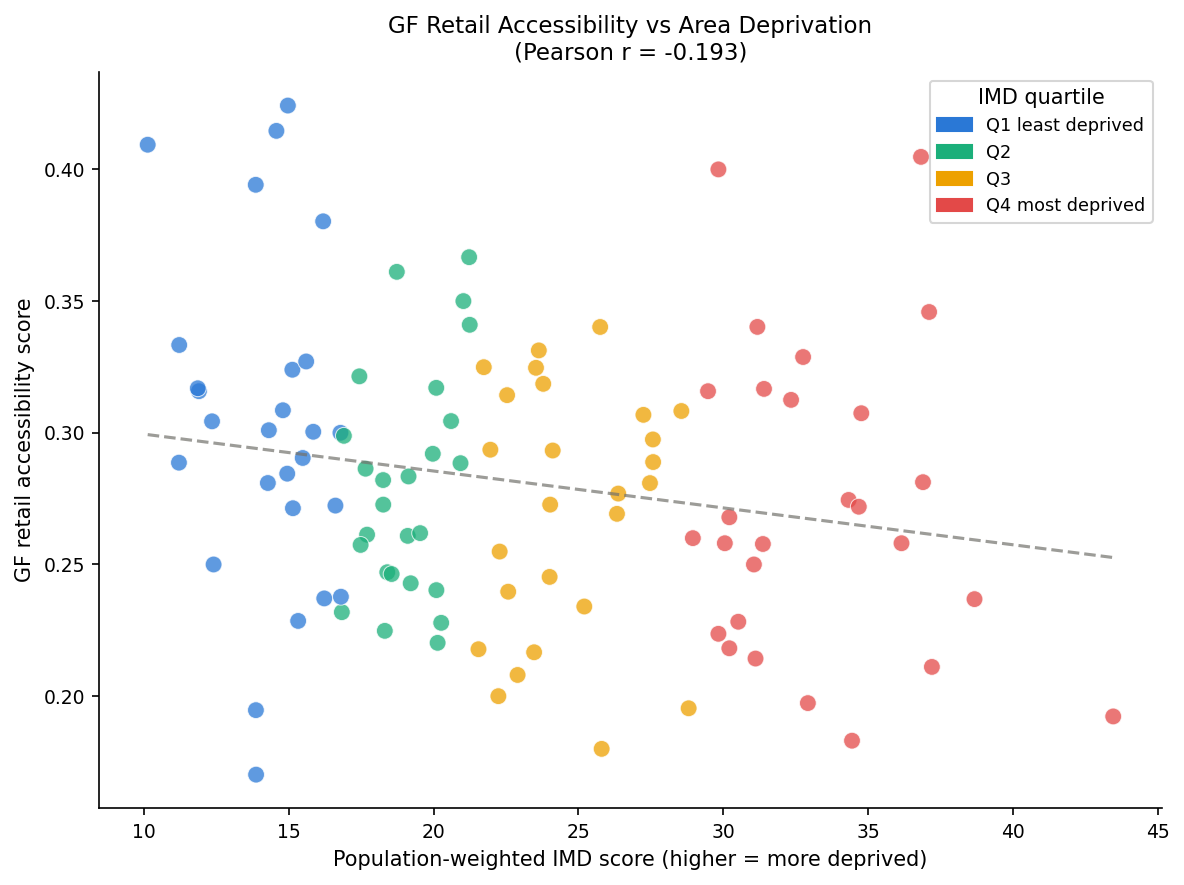

Saved 2c.


In [11]:
# Plot 2c — Retail accessibility vs IMD scatter
fig, ax = plt.subplots(figsize=(8, 6))

imd_quartile = pd.qcut(df['imd_score_weighted'], q=4,
                        labels=['Q1 least deprived', 'Q2', 'Q3', 'Q4 most deprived'])
colors_q = {'Q1 least deprived': BLUE, 'Q2': GREEN,
            'Q3': AMBER, 'Q4 most deprived': RED}
color_vals = [colors_q[q] for q in imd_quartile]

ax.scatter(df['imd_score_weighted'], df['retail_accessibility_score'],
           c=color_vals, alpha=0.75, s=65, edgecolors='white', linewidth=0.5)

z = np.polyfit(df['imd_score_weighted'], df['retail_accessibility_score'], 1)
x_line = np.linspace(df['imd_score_weighted'].min(),
                     df['imd_score_weighted'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), color=GREY,
        linewidth=1.5, linestyle='--', alpha=0.7)

corr = df['imd_score_weighted'].corr(df['retail_accessibility_score'])
ax.set_xlabel('Population-weighted IMD score (higher = more deprived)')
ax.set_ylabel('GF retail accessibility score')
ax.set_title(f'GF Retail Accessibility vs Area Deprivation\n'
             f'(Pearson r = {corr:.3f})')

handles = [mpatches.Patch(color=c, label=l) for l, c in colors_q.items()]
ax.legend(handles=handles, title='IMD quartile', fontsize=8.5)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/EDA_02c_retail_vs_imd.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved 2c.")

In [14]:
# ── SECTION 3: AXIS 3 — AREA DEPRIVATION ──────────────────────────────────

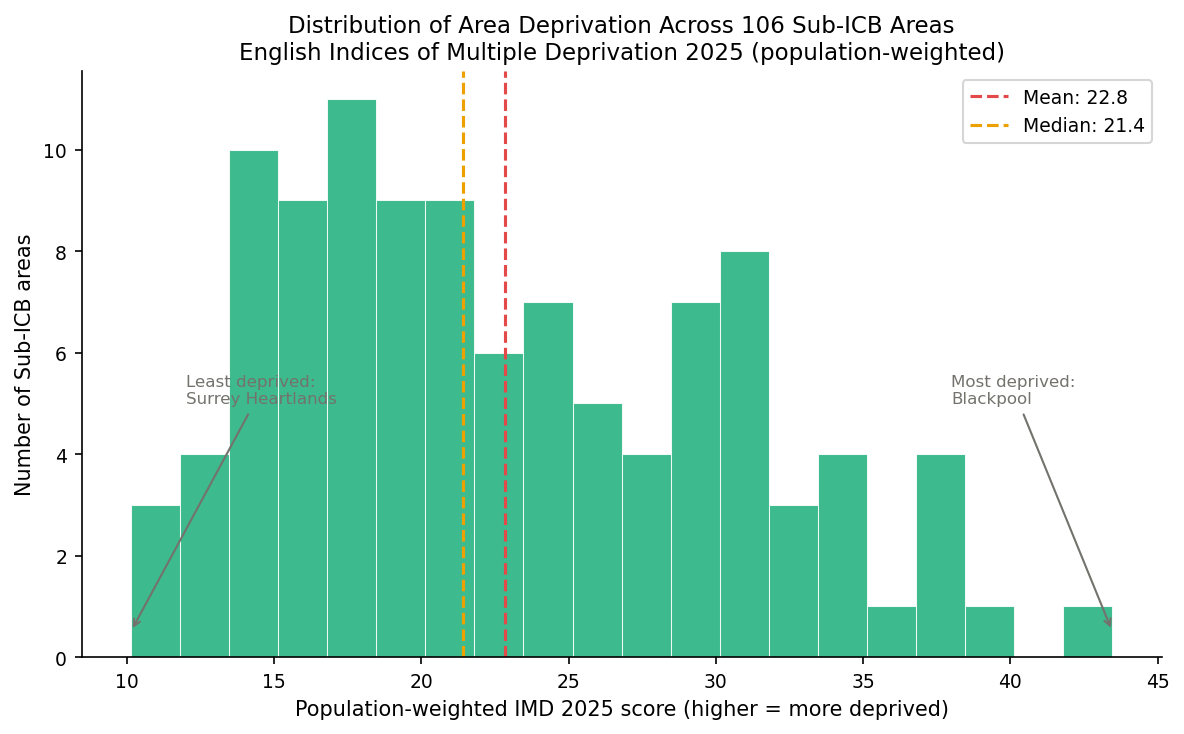

Saved 3a.


In [15]:
# Plot 3a — Distribution of weighted IMD score
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df['imd_score_weighted'], bins=20, color=GREEN,
        alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axvline(df['imd_score_weighted'].mean(), color=RED,
           linewidth=1.5, linestyle='--',
           label=f"Mean: {df['imd_score_weighted'].mean():.1f}")
ax.axvline(df['imd_score_weighted'].median(), color=AMBER,
           linewidth=1.5, linestyle='--',
           label=f"Median: {df['imd_score_weighted'].median():.1f}")
ax.set_xlabel('Population-weighted IMD 2025 score (higher = more deprived)')
ax.set_ylabel('Number of Sub-ICB areas')
ax.set_title('Distribution of Area Deprivation Across 106 Sub-ICB Areas\n'
             'English Indices of Multiple Deprivation 2025 (population-weighted)')
ax.legend()

# annotate extremes
most_dep = df.loc[df['imd_score_weighted'].idxmax(), 'org_name'].replace('NHS ', '')
least_dep = df.loc[df['imd_score_weighted'].idxmin(), 'org_name'].replace('NHS ', '')
ax.annotate(f'Most deprived:\n{most_dep.title()}',
            xy=(df['imd_score_weighted'].max(), 0.5),
            xytext=(38, 5),
            arrowprops=dict(arrowstyle='->', color=GREY, lw=1),
            fontsize=8, color=GREY)
ax.annotate(f'Least deprived:\n{least_dep.title()}',
            xy=(df['imd_score_weighted'].min(), 0.5),
            xytext=(12, 5),
            arrowprops=dict(arrowstyle='->', color=GREY, lw=1),
            fontsize=8, color=GREY)

plt.tight_layout()
plt.savefig(f'{FIG_PATH}/EDA_03a_imd_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved 3a.")

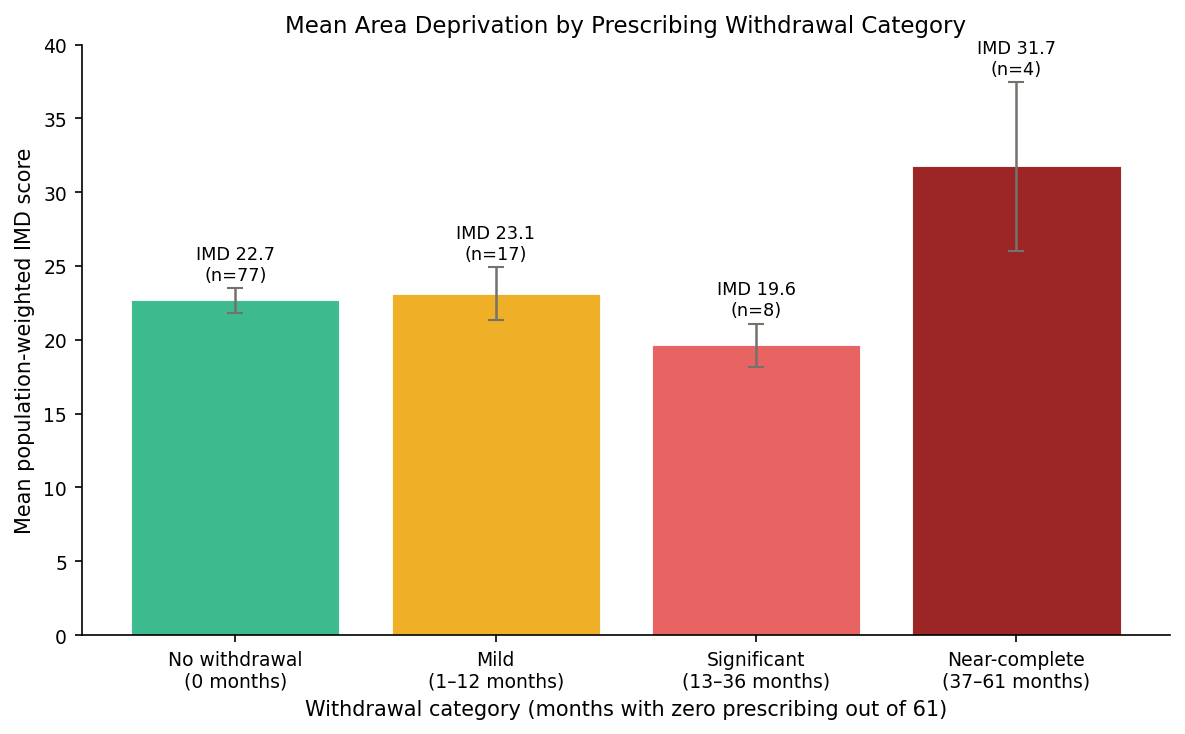

Saved 3b.


In [16]:
# Plot 3b — IMD by prescribing withdrawal category
fig, ax = plt.subplots(figsize=(8, 5))

withdrawal_cats = pd.cut(df['months_zero'],
    bins=[-1, 0, 12, 36, 61],
    labels=['No withdrawal\n(0 months)', 'Mild\n(1–12 months)',
            'Significant\n(13–36 months)', 'Near-complete\n(37–61 months)'])
df['withdrawal_cat'] = withdrawal_cats

imd_by_withdrawal = df.groupby('withdrawal_cat', observed=True)['imd_score_weighted'].agg(
    ['mean', 'std', 'count']).reset_index()
imd_by_withdrawal['se'] = imd_by_withdrawal['std'] / np.sqrt(imd_by_withdrawal['count'])

colors_w = [GREEN, AMBER, RED, '#8b0000']
bars = ax.bar(imd_by_withdrawal['withdrawal_cat'],
              imd_by_withdrawal['mean'],
              color=colors_w, alpha=0.85, edgecolor='white', linewidth=0.5,
              yerr=imd_by_withdrawal['se'], capsize=4,
              error_kw=dict(ecolor=GREY, lw=1.2))

for bar, (_, row) in zip(bars, imd_by_withdrawal.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            row['mean'] + row['se'] + 0.3,
            f"IMD {row['mean']:.1f}\n(n={int(row['count'])})",
            ha='center', va='bottom', fontsize=8.5)

ax.set_ylabel('Mean population-weighted IMD score')
ax.set_xlabel('Withdrawal category (months with zero prescribing out of 61)')
ax.set_title('Mean Area Deprivation by Prescribing Withdrawal Category')
ax.set_ylim(0, 40)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/EDA_03b_imd_by_withdrawal.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved 3b.")

In [23]:
# ── SECTION 4: PAIRWISE RELATIONSHIPS BETWEEN AXES ────────────────────────

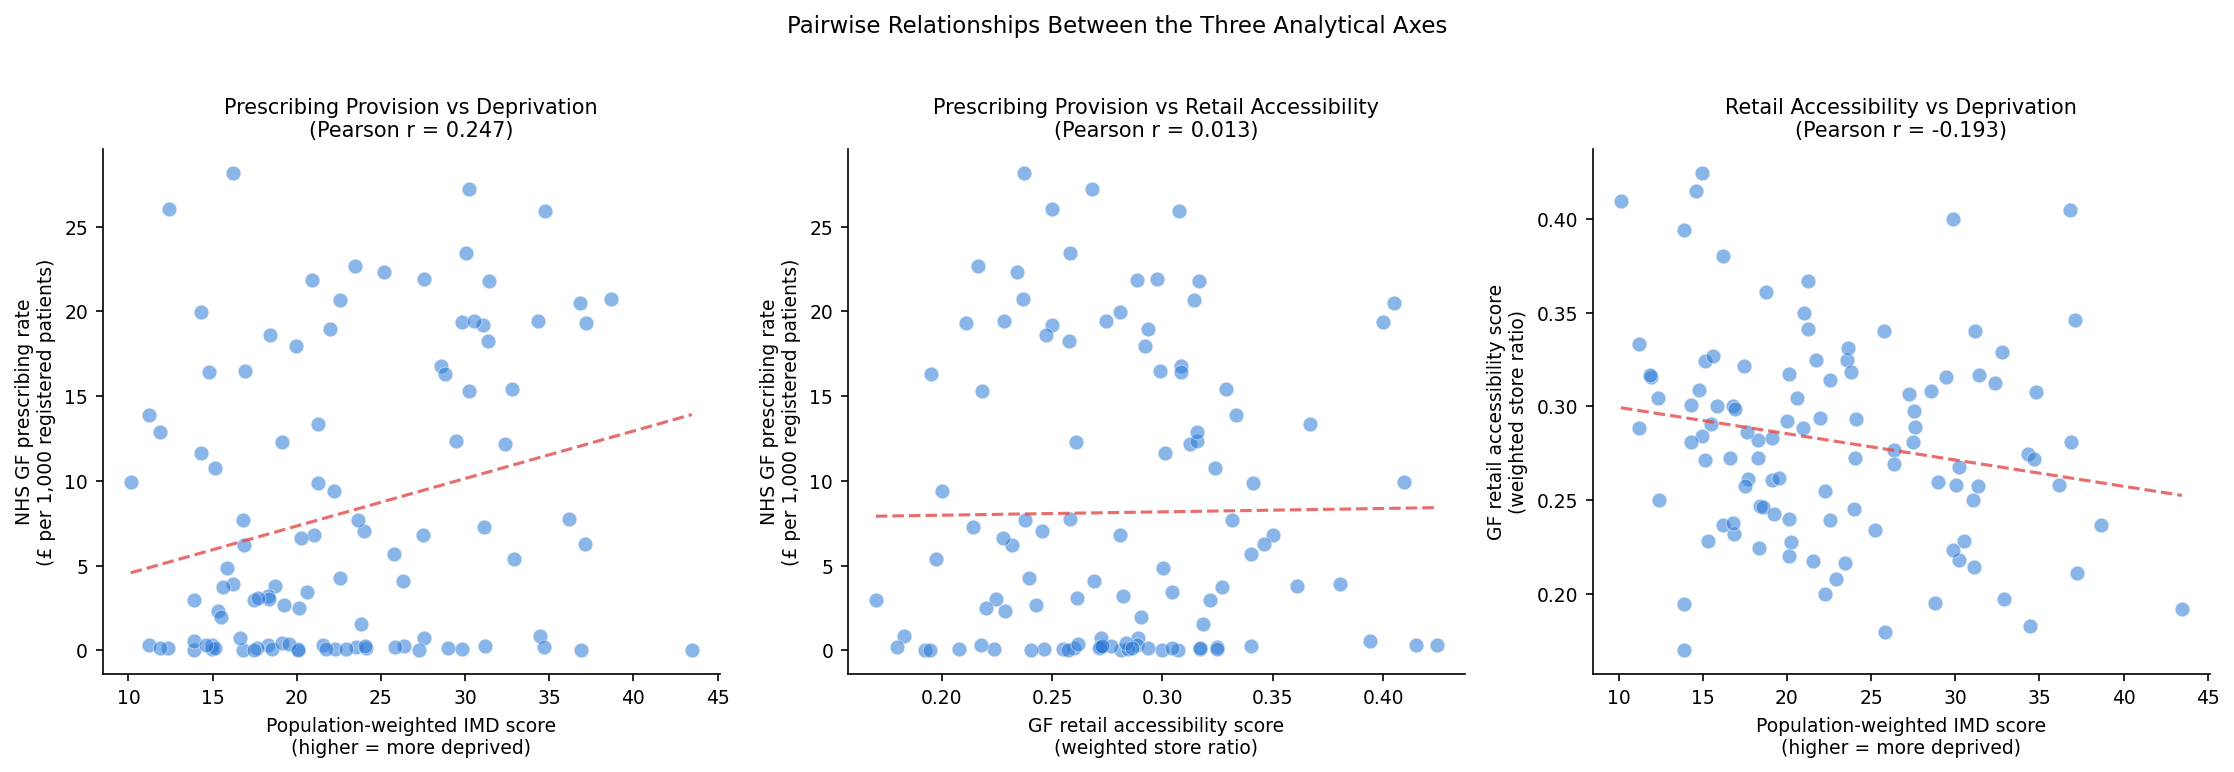

Saved 4 revised.


In [24]:
# Plot 4 — revised: three pairwise scatter plots, clean style
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pairs = [
    ('imd_score_weighted', 'prescribing_rate_recent',
     'Population-weighted IMD score\n(higher = more deprived)',
     'NHS GF prescribing rate\n(£ per 1,000 registered patients)'),
    ('retail_accessibility_score', 'prescribing_rate_recent',
     'GF retail accessibility score\n(weighted store ratio)',
     'NHS GF prescribing rate\n(£ per 1,000 registered patients)'),
    ('imd_score_weighted', 'retail_accessibility_score',
     'Population-weighted IMD score\n(higher = more deprived)',
     'GF retail accessibility score\n(weighted store ratio)'),
]

titles = [
    'Prescribing Provision vs Deprivation',
    'Prescribing Provision vs Retail Accessibility',
    'Retail Accessibility vs Deprivation',
]

for ax, (x_var, y_var, x_lab, y_lab), title in zip(axes, pairs, titles):
    ax.scatter(df[x_var], df[y_var], color=BLUE, alpha=0.55,
               s=50, edgecolors='white', linewidth=0.4)
    z = np.polyfit(df[x_var], df[y_var], 1)
    x_line = np.linspace(df[x_var].min(), df[x_var].max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), color=RED,
            linewidth=1.5, linestyle='--', alpha=0.8)
    r = df[x_var].corr(df[y_var])
    ax.set_xlabel(x_lab, fontsize=9)
    ax.set_ylabel(y_lab, fontsize=9)
    ax.set_title(f'{title}\n(Pearson r = {r:.3f})', fontsize=10)

plt.suptitle('Pairwise Relationships Between the Three Analytical Axes',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/EDA_04_pairwise_scatter.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved 4 revised.")

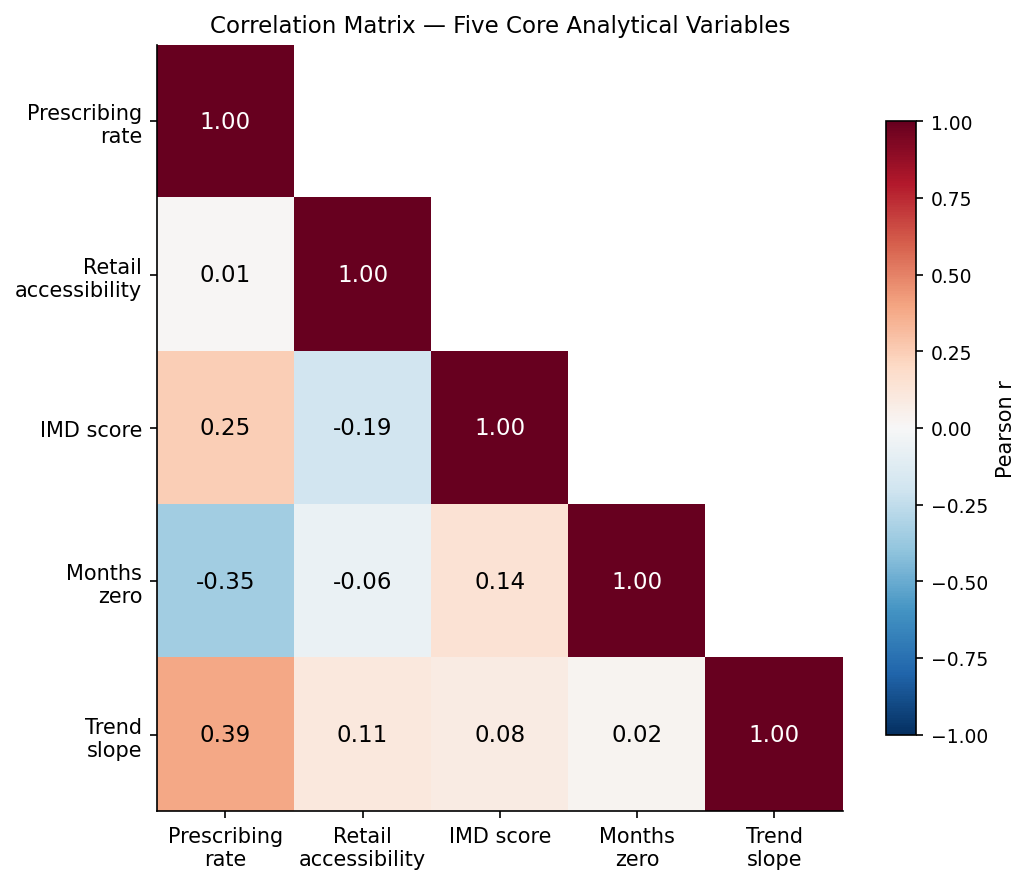

Saved.


In [25]:
fig, ax = plt.subplots(figsize=(7, 6))

corr_vars = ['prescribing_rate_recent', 'retail_accessibility_score',
             'imd_score_weighted', 'months_zero', 'trend_slope']
corr_labels = ['Prescribing\nrate', 'Retail\naccessibility',
               'IMD score', 'Months\nzero', 'Trend\nslope']

corr_matrix = df[corr_vars].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
corr_masked = corr_matrix.copy()
corr_masked[mask] = np.nan

im = ax.imshow(corr_masked, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(corr_labels, fontsize=10)
ax.set_yticklabels(corr_labels, fontsize=10)

for i in range(5):
    for j in range(5):
        if not mask[i, j]:
            val = corr_matrix.iloc[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=11, color='white' if abs(val) > 0.5 else 'black')

ax.set_title('Correlation Matrix — Five Core Analytical Variables', fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/EDA_04c_correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved.")

In [26]:
# ── SECTION 5: JOINT DISTRIBUTION — MOTIVATION FOR MULTIVARIATE ANALYSIS ──

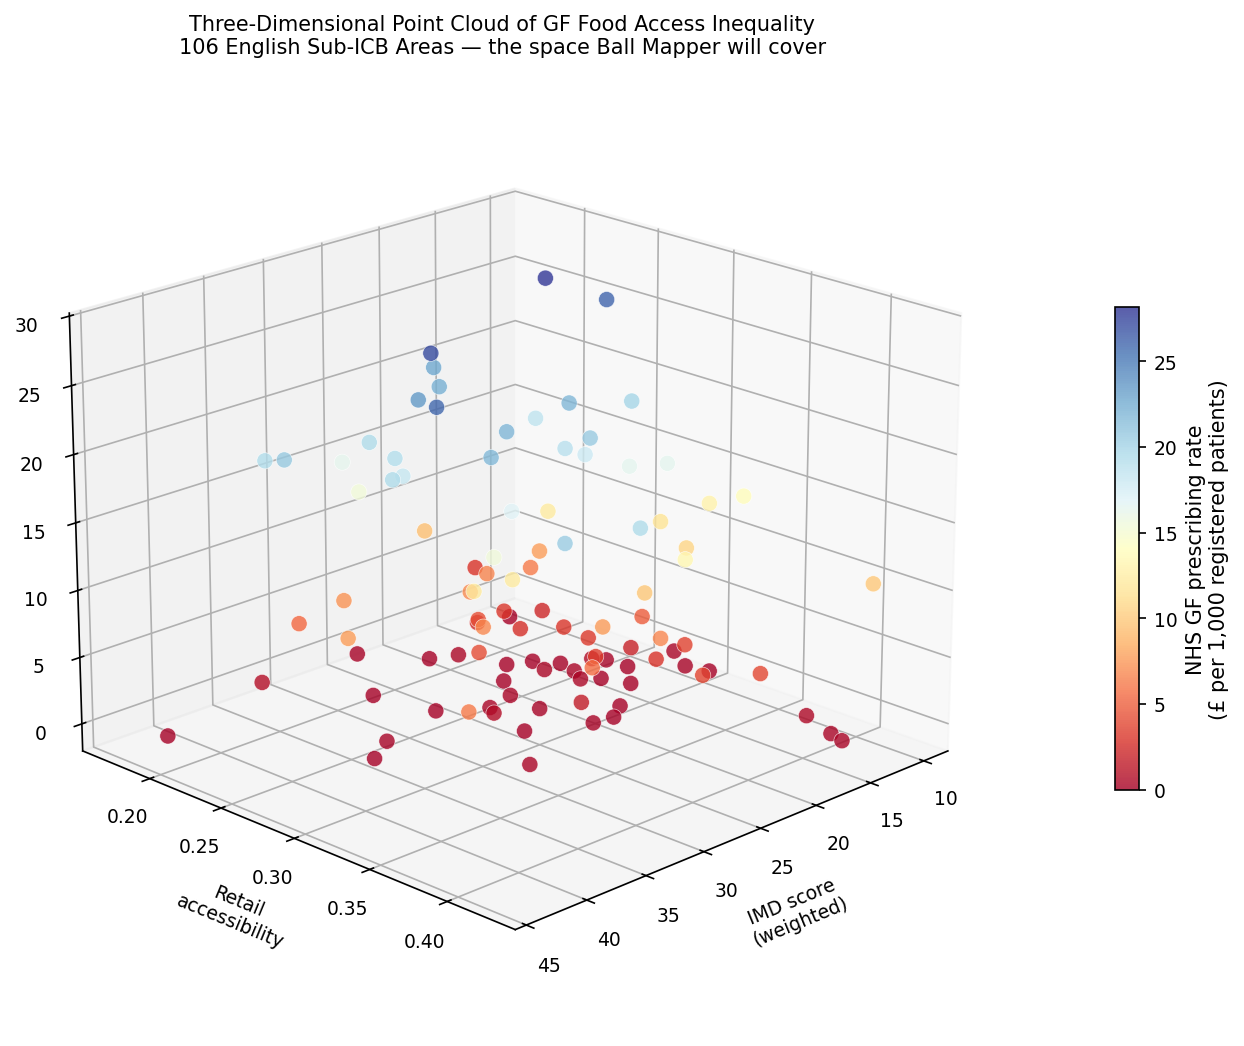

Saved 5a.


In [27]:

# Plot 5a — 3D scatter of all three axes
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['imd_score_weighted'],
                     df['retail_accessibility_score'],
                     df['prescribing_rate_recent'],
                     c=df['prescribing_rate_recent'],
                     cmap='RdYlBu', s=60, alpha=0.8,
                     edgecolors='white', linewidth=0.3)

plt.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1,
             label='NHS GF prescribing rate\n(£ per 1,000 registered patients)')

ax.set_xlabel('IMD score\n(weighted)', fontsize=9, labelpad=8)
ax.set_ylabel('Retail\naccessibility', fontsize=9, labelpad=8)
ax.set_zlabel('Prescribing\nrate', fontsize=9, labelpad=8)
ax.set_title('Three-Dimensional Point Cloud of GF Food Access Inequality\n'
             '106 English Sub-ICB Areas — the space Ball Mapper will cover',
             fontsize=10)
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.savefig(f'{FIG_PATH}/EDA_05a_3d_pointcloud.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved 5a.")

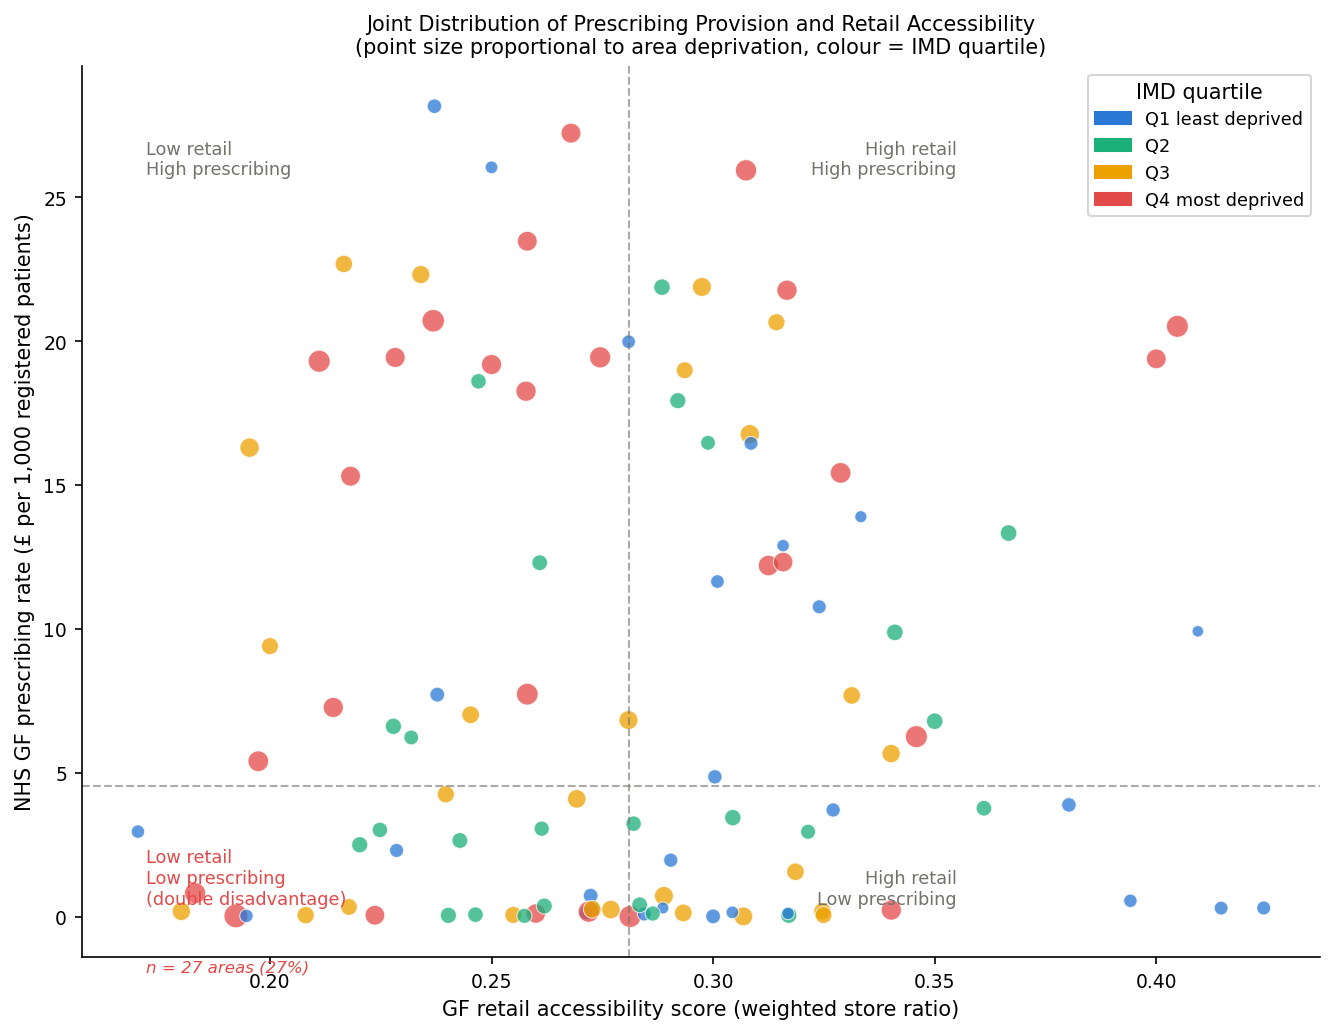

Saved 5b.


In [28]:
# Plot 5b — Quadrant analysis: prescribing x retail, sized by IMD
fig, ax = plt.subplots(figsize=(9, 7))

presc_median = df['prescribing_rate_recent'].median()
retail_median = df['retail_accessibility_score'].median()

# colour by IMD quartile
imd_quartile = pd.qcut(df['imd_score_weighted'], q=4,
                        labels=['Q1 least deprived', 'Q2', 'Q3', 'Q4 most deprived'])
colors_iq = {'Q1 least deprived': BLUE, 'Q2': GREEN,
             'Q3': AMBER, 'Q4 most deprived': RED}
color_vals = [colors_iq[q] for q in imd_quartile]

ax.scatter(df['retail_accessibility_score'], df['prescribing_rate_recent'],
           c=color_vals, s=df['imd_score_weighted'] * 3,
           alpha=0.75, edgecolors='white', linewidth=0.5)

# Quadrant lines
ax.axvline(retail_median, color=GREY, linewidth=1, linestyle='--', alpha=0.6)
ax.axhline(presc_median, color=GREY, linewidth=1, linestyle='--', alpha=0.6)

# Quadrant labels
ax.text(0.172, 27, 'Low retail\nHigh prescribing', fontsize=8.5,
        color=GREY, va='top')
ax.text(0.355, 27, 'High retail\nHigh prescribing', fontsize=8.5,
        color=GREY, va='top', ha='right')
ax.text(0.172, 0.3, 'Low retail\nLow prescribing\n(double disadvantage)',
        fontsize=8.5, color=RED, va='bottom', fontweight='500')
ax.text(0.355, 0.3, 'High retail\nLow prescribing', fontsize=8.5,
        color=GREY, va='bottom', ha='right')

# Count areas per quadrant
dd = ((df['prescribing_rate_recent'] < presc_median) &
      (df['retail_accessibility_score'] < retail_median)).sum()
ax.text(0.172, -1.5, f'n = {dd} areas (27%)', fontsize=8,
        color=RED, va='top', style='italic')

ax.set_xlabel('GF retail accessibility score (weighted store ratio)', fontsize=10)
ax.set_ylabel('NHS GF prescribing rate (£ per 1,000 registered patients)', fontsize=10)
ax.set_title('Joint Distribution of Prescribing Provision and Retail Accessibility\n'
             '(point size proportional to area deprivation, colour = IMD quartile)',
             fontsize=10)

handles = [mpatches.Patch(color=c, label=l) for l, c in colors_iq.items()]
ax.legend(handles=handles, title='IMD quartile', fontsize=8.5, loc='upper right')

plt.tight_layout()
plt.savefig(f'{FIG_PATH}/EDA_05b_quadrant.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved 5b.")